In [1]:
import os
import numpy as np
import yaml
import matplotlib.pyplot as plt
import healpy as hp
import heracles
import heracles.dices as dices
from heracles.io import read

In [2]:
nside = 1024
npix = hp.nside2npix(nside)
mask = np.ones(npix)
pixel_theta, pixel_phi = hp.pix2ang(nside, np.arange(hp.nside2npix(nside)))
mask_type = 'half_sky'
if mask_type == 'Patch':
    mask[np.pi/3 > pixel_theta] = 0.0
    mask[pixel_theta > 2*np.pi/3] = 0.0
    mask[pixel_phi > np.pi/2] = 0.0
    mask[np.pi/8> pixel_phi] = 0.0

if mask_type == 'One third cover':
    mask[np.pi/3 > pixel_theta] = 0.0

if mask_type == 'half_sky':
        mask[np.pi/2 > pixel_theta] = 0.0

if mask_type == 'Two thirds cover':
        mask[2*np.pi/3 > pixel_theta] = 0.0

path = '/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/lognormal_sims/'
hp.write_map(path+f"dummy_mask.fits", mask, overwrite=True)

setting the output map dtype to [dtype('float64')]


In [3]:
cls_pols = hp.read_cl(f"/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/{mask_type}/cls_pols/cls_data_pols.fits")
#cls_pols_raw = hp.read_cl(f"/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/{mask_type}/cls_pols/cls_data_pols_raw_1.fits")
cls = heracles.read(f"/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/{mask_type}/cls/cls_data_1.fits")
#corrs_pols = hp.read_cl(f"/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/{mask_type}/cls_pols/corr_data_pols_1.fits")
#cls_mask_pols = hp.read_cl(f"/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/{mask_type}/cls_pols/cls_mask_pols_1.fits")
#cls_mask = heracles.read(f"/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/{mask_type}/cls/cls_mask.fits")
cls_nu = heracles.read(f"/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/{mask_type}/cls_nu/cls_data_nu_1.fits")

/tmp/ipykernel_80552/314116912.py:23: RuntimeWarning: invalid value encountered in divide
  axs[1].semilogx((ee - _ee) / _ee)
/tmp/ipykernel_80552/314116912.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


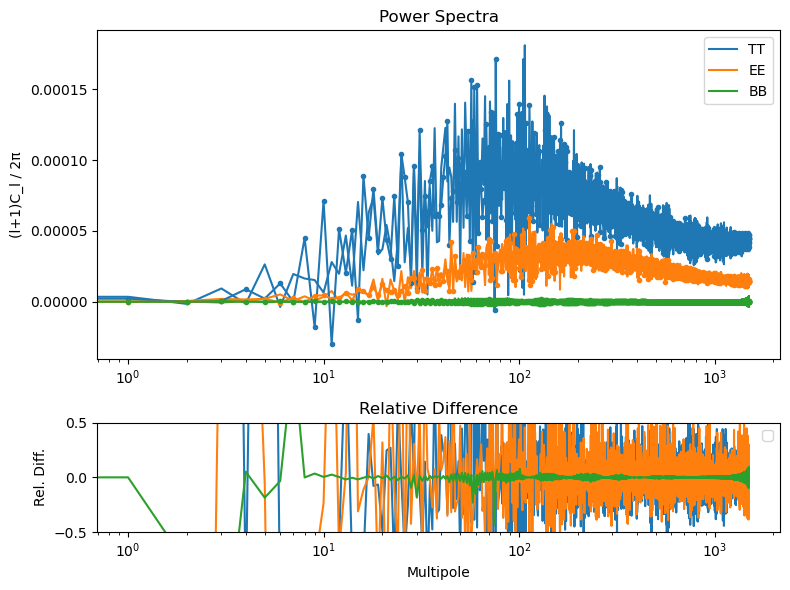

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})

# Main panel: plot the curves
l = np.arange(1500+1)
tt = cls_pols[0]
ee = cls_pols[1]
bb = cls_pols[2]
_tt = cls_nu['POS', 'POS', 1, 1]
_ee = cls_nu['SHE', 'SHE', 1, 1][0, 0]
_bb = cls_nu['SHE', 'SHE', 1, 1][1, 1]
axs[0].semilogx(l, l * tt, label='TT')
axs[0].semilogx(l, l * ee, label='EE')
axs[0].semilogx(l, l * bb, label='BB')
axs[0].semilogx(l, l * _tt, 'C0.-')
axs[0].semilogx(l, l * _ee, 'C1.-')
axs[0].semilogx(l, l * _bb, 'C2.-')
axs[0].legend()
axs[0].set_ylabel('(l+1)C_l / 2π')
axs[0].set_title('Power Spectra')

# Avoid division by zero
axs[1].semilogx((tt - _tt) / _tt)
axs[1].semilogx((ee - _ee) / _ee)
axs[1].semilogx((bb - _bb) / _tt)
axs[1].set_ylim([-0.5, 0.5])
axs[1].set_xlabel('Multipole')
axs[1].set_ylabel('Rel. Diff.')
axs[1].legend()
axs[1].set_title('Relative Difference')

plt.tight_layout()
plt.show()

# SpaceBorne Vs DICES

In [5]:
config_path = "scripts/sims_config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)
n = config['nsims']
nside = config['nside']
lmax = config['lmax']
mode = config['mode']  # "lognormal" or "gaussian"
mask_type = config['mask_type']  # Default to 'Patch' if not specified
binned = False #True
apply_mask = True
nbins = 3

output_path = f"{mode}_dices/"
output_path = "./masked_"+output_path

nlbins = config.get('nlbins', 20)  # Default to 20 if not specified
l = np.arange(lmax+1)
ls = np.arange(lmax+1)
ledges = np.logspace(np.log10(10), np.log10(lmax), nlbins + 1)
lgrid = (ledges[1:] + ledges[:-1]) / 2

## Comparison

In [8]:
path = f"./{mask_type}/"
cls = {}
nu_cls = {}
pp_cls = {}
pm_cls = {}
pols_cls = {}
dpols_cls = {}
for i in range(1, n+1):
    print(f"Loading sim {i}", end='\r')
    cls[i] = heracles.read(path+f"/cls/cls_data_{i}.fits")
    nu_cls[i] = heracles.read(path+f"/cls_nu/cls_data_nu_{i}.fits")
    pp_cls[i] = heracles.read(path+f"/cls_pp/cls_data_pp_{i}.fits")
    pm_cls[i] = heracles.read(path+f"/cls_pm/cls_data_pm_{i}.fits")
    pols_cls[i] = heracles.read(path+f"/cls_pols/cls_data_pols_{i}.fits")
    dpols_cls[i] = heracles.read(path+f"/cls_pols/cls_data_decoupled_pols_{i}.fits")

In [10]:
inv_cqs = {}
nmt_cqs = {}
for i in range(1, n+1):
    print(f"Loading sim {i}", end='\r')
    inv_cqs[i] = heracles.read(path+f"/cls_inv/cqs_data_inv_{i}.fits")
    nmt_cqs[i] = heracles.read(path+f"/cls_nmt/cls_data_nmt_np_{i}.fits")
cqs = heracles.binned(cls, ledges)
nu_cqs = heracles.binned(nu_cls, ledges)
pp_cqs = heracles.binned(pp_cls, ledges)
pm_cqs = heracles.binned(pm_cls, ledges)
pols_cqs = heracles.binned(pols_cls, ledges)
dpols_cqs = heracles.binned(dpols_cls, ledges)

In [11]:
def get_cls_mean(cls_dict):
    n_keys = list(cls_dict.keys())
    f_keys = list(cls_dict[n_keys[0]].keys())
    cls_mean = {}
    for f_key in f_keys:
        cl = np.mean([cls_dict[i][f_key] for i in n_keys], axis=0)
        cls_mean[f_key] = heracles.Result(cl, axis=cls_dict[n_keys[0]][f_key].axis)
    return cls_mean

In [12]:
cls_m = get_cls_mean(cls)
nu_cls_m = get_cls_mean(nu_cls)
pp_cls_m = get_cls_mean(pp_cls)
pm_cls_m = get_cls_mean(pm_cls)
pols_cls_m = get_cls_mean(pols_cls)
dpols_cls_m = get_cls_mean(dpols_cls)

cqs_m = get_cls_mean(cqs)
inv_cqs_m = get_cls_mean(inv_cqs)
nu_cqs_m = get_cls_mean(nu_cqs)
pp_cqs_m = get_cls_mean(pp_cqs)
pm_cqs_m = get_cls_mean(pm_cqs)
pols_cqs_m = get_cls_mean(pols_cqs)
dpols_cqs_m = get_cls_mean(dpols_cqs)
nmt_cqs_m = get_cls_mean(nmt_cqs)

In [13]:
theory_cls = heracles.read(f"{mask_type}/cls/cls_theory.fits")

fl = -np.sqrt((ls+2)*(ls+1)*ls*(ls-1))
fl /= np.clip(ls*(ls+1), 1, None)

_theory_cls = {}
_theory_cls[("POS", "POS", 1, 1)] = heracles.Result(theory_cls["W1xW1"].array, ell=ls)

c = np.zeros((2, 2, lmax+1))
c[0, 0, :] = theory_cls["W2xW2"].array * fl**2
_theory_cls[("SHE", "SHE", 1, 1)] = heracles.Result(c)

c = np.zeros((2, lmax+1))
c[0, :] = theory_cls["W1xW2"].array * fl
_theory_cls[("POS", "SHE", 1, 1)] = heracles.Result(c)

_theory_cqs = heracles.binned(_theory_cls, ledges)


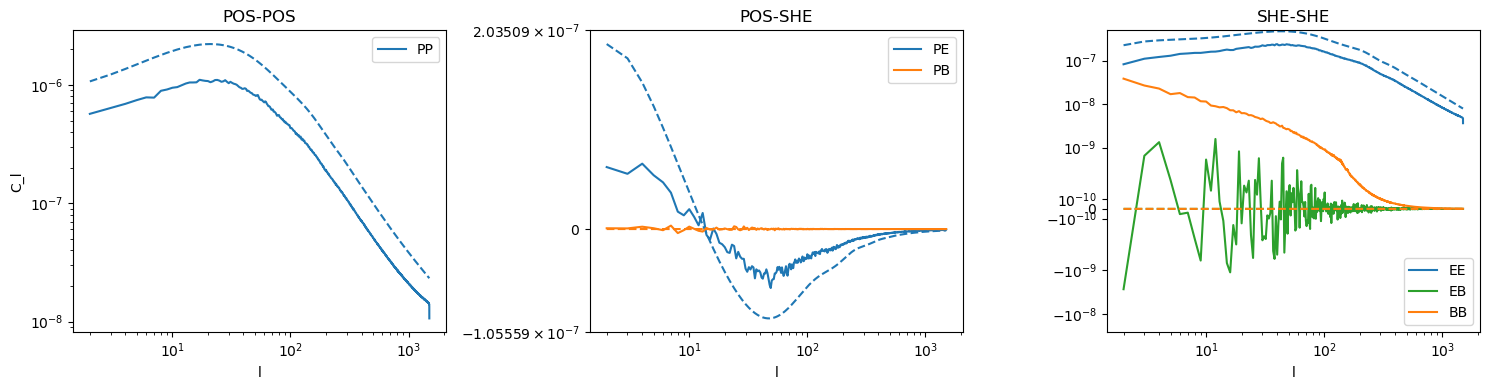

In [14]:
# Create a figure with 1 row and 3 columns of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

# POS POS
axs[0].plot(l[2:], cls_m[("POS", "POS", 1, 1)].array[2:], color='C0', label='PP')
axs[0].plot(l[2:], _theory_cls[("POS", "POS", 1, 1)].array[2:], color='C0', linestyle='--')
axs[0].legend()
axs[0].set_title("POS-POS")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel("l")
axs[0].set_ylabel("C_l")

# POS SHE
axs[1].plot(l[2:], cls_m[("POS", "SHE", 1, 1)].array[0][2:], color='C0', label='PE')
axs[1].plot(l[2:], _theory_cls[("POS", "SHE", 1, 1)].array[0][2:], color='C0', linestyle='--')
axs[1].plot(l[2:], cls_m[("POS", "SHE", 1, 1)].array[1][2:], color='C1', label='PB')
axs[1].plot(l[2:], _theory_cls[("POS", "SHE", 1, 1)].array[1][2:], color='C1', linestyle='--')
axs[1].legend()
axs[1].set_title("POS-SHE")
axs[1].set_xscale('log')
axs[1].set_yscale('symlog')
axs[1].set_xlabel("l")

# SHE SHE
axs[2].plot(l[2:], cls_m[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', label='EE')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', linestyle='--')
axs[2].plot(l[2:], cls_m[("SHE", "SHE", 1, 1)].array[0, 1][2:], color='C2', label='EB')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[0, 1][2:], color='C2', linestyle='--')
axs[2].plot(l[2:], cls_m[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', label='BB')
axs[2].plot(l[2:], _theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', linestyle='--')
axs[2].legend()
axs[2].set_title("SHE-SHE")
axs[2].set_xscale('log')
axs[2].set_yscale('symlog', linthresh=5e-10)
axs[2].set_xlabel("l")

# Adjust layout
plt.tight_layout()
plt.show()

In [15]:
ensemble_cov = heracles.read(f"{mask_type}/covs/cov_cls.fits")
ensemble_covqq = heracles.read(f"{mask_type}/covs/cov_cqs.fits")

In [ ]:
nu_ensemble_cov = heracles.read(f"{mask_type}/covs/cov_nu_cls.fits")
pp_ensemble_cov = heracles.read(f"{mask_type}/covs/cov_pp_cls.fits")
pm_ensemble_cov = heracles.read(f"{mask_type}/covs/cov_pm_cls.fits")
pols_ensemble_cov = heracles.read(f"{mask_type}/covs/cov_pols_cls.fits")
dpols_ensemble_cov = heracles.read(f"{mask_type}/covs/cov_decoupled_pols_cls.fits")

inv_ensemble_covqq = heracles.read(f"{mask_type}/covs/cov_inv_cqs.fits")
nu_ensemble_covqq = heracles.read(f"{mask_type}/covs/cov_nu_cqs.fits")
pp_ensemble_covqq = heracles.read(f"{mask_type}/covs/cov_pp_cqs.fits")
pm_ensemble_covqq = heracles.read(f"{mask_type}/covs/cov_pm_cqs.fits")
nmt_ensemble_covqq = heracles.read(f"{mask_type}/covs/cov_nmt_cqs.fits")
pols_ensemble_covqq = heracles.read(f"{mask_type}/covs/cov_pols_cqs.fits")
dpols_ensemble_covqq = heracles.read(f"{mask_type}/covs/cov_dpols_cqs.fits")


In [ ]:
pols_ensemble_cov = dices.jackknife_covariance(pols_cls, nd=0)
pols_ensemble_covqq = dices.jackknife_covariance(pols_cqs, nd=0)

dpols_ensemble_cov = dices.jackknife_covariance(dpols_cls, nd=0)
dpols_ensemble_covqq = dices.jackknife_covariance(dpols_cqs, nd=0)

In [ ]:
# Flattened ensemble Covariance
flat_ensemble_cov = dices.flatten(ensemble_covqq)
flat_ensemble_corr = flat_ensemble_cov / np.sqrt(
    np.diag(flat_ensemble_cov)[:, None] * np.diag(flat_ensemble_cov)[None, :]
)
# Flattened inverse Covariance
flat_inv_ensemble_cov = dices.flatten(inv_ensemble_covqq)
flat_inv_ensemble_corr = flat_inv_ensemble_cov / np.sqrt(
    np.diag(flat_inv_ensemble_cov)[:, None] * np.diag(flat_inv_ensemble_cov)[None, :]
)
# Flattened nu ensemble Covariance
flat_nu_ensemble_cov = dices.flatten(nu_ensemble_covqq)
flat_nu_ensemble_corr = flat_nu_ensemble_cov / np.sqrt(
    np.diag(flat_nu_ensemble_cov)[:, None] * np.diag(flat_nu_ensemble_cov)[None, :]
)
# Flattened PolSpice plus Covariance
flat_pp_ensemble_cov = dices.flatten(pp_ensemble_covqq)
flat_pp_ensemble_corr = flat_pp_ensemble_cov / np.sqrt(
    np.diag(flat_pp_ensemble_cov)[:, None] * np.diag(flat_pp_ensemble_cov)[None, :]
)
# Flattened PolSpice minus Covariance
flat_pm_ensemble_cov = dices.flatten(pm_ensemble_covqq)
flat_pm_ensemble_corr = flat_pm_ensemble_cov / np.sqrt(
    np.diag(flat_pm_ensemble_cov)[:, None] * np.diag(flat_pm_ensemble_cov)[None, :]
)
# Flattened PolSpice polarization Covariance
flat_pols_ensemble_cov = dices.flatten(pols_ensemble_covqq)
flat_pols_ensemble_corr = flat_pols_ensemble_cov / np.sqrt(
    np.diag(flat_pols_ensemble_cov)[:, None] * np.diag(flat_pols_ensemble_cov)[None, :]
)
# Flattened PolSpice decoupled polarization Covariance
flat_dpols_ensemble_cov = dices.flatten(dpols_ensemble_covqq)
flat_dpols_ensemble_corr = flat_dpols_ensemble_cov / np.sqrt(
    np.diag(flat_dpols_ensemble_cov)[:, None] * np.diag(flat_dpols_ensemble_cov)[None, :]
)

In [ ]:
print("Shape of the flattened ensemble covariance matrix:", flat_ensemble_cov.shape)
print("Shape of the flattened inverse ensemble covariance matrix:", flat_inv_ensemble_cov.shape)
print("Shape of the flattened nu ensemble covariance matrix:", flat_nu_ensemble_cov.shape)
print("Shape of the flattened PolSpice plus ensemble covariance matrix:", flat_pp_ensemble_cov.shape)
print("Shape of the flattened PolSpice minus ensemble covariance matrix:", flat_pm_ensemble_cov.shape)
print("Shape of the flattened PolSpice polarization ensemble covariance matrix:", flat_pols_ensemble_cov.shape)
print("Shape of the flattened PolSpice decoupled polarization ensemble covariance matrix:", flat_dpols_ensemble_cov.shape)

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 15))

# Flattened Ensemble Covariance
im1 = axes[0].imshow(flat_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[0].set_title("Ensemble Covariance")

# Flattened Inverse covariance
im2 = axes[1].imshow(flat_inv_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[1].set_title("Inverse Covariance")

# Flattened Natural unmixing Covariance
im3 = axes[2].imshow(flat_nu_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[2].set_title("Natural Unmixing Covariance")

# Flattened PolSpice Plus Covariance
im3 = axes[3].imshow(flat_pp_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[3].set_title("PolSpice Plus Covariance")

# Flattened PolSpice Minus Covariance
im3 = axes[4].imshow(flat_pm_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[4].set_title("PolSpice Minus Covariance")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 15))

# Flattened Ensemble Covariance
im1 = axes[0].imshow(flat_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[0].set_title("Ensemble Covariance")

# Flattened Inverse covariance
im2 = axes[1].imshow(flat_inv_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[1].set_title("Inverse Covariance")

# Flattened Natural unmixing Covariance
im3 = axes[2].imshow(flat_nu_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[2].set_title("Natural Unmixing Covariance")

# Flattened PolSpice Plus Covariance
im3 = axes[3].imshow(flat_pols_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[3].set_title("PolSpice Covariance")

# Flattened PolSpice Minus Covariance
im3 = axes[4].imshow(flat_dpols_ensemble_corr, cmap="seismic", vmin=-1, vmax=1)
axes[4].set_title("PolSpice decouple Covariance")

plt.tight_layout()
plt.show()

In [ ]:
# Compute eigenvalues
eig_ens = np.linalg.eigvalsh(flat_ensemble_cov)
eig_inv_ens = np.linalg.eigvalsh(flat_inv_ensemble_cov)
eig_nu_ens = np.linalg.eigvalsh(flat_nu_ensemble_cov)
eig_pp_ens = np.linalg.eigvalsh(flat_pp_ensemble_cov)
eig_pm_ens = np.linalg.eigvalsh(flat_pm_ensemble_cov)

# Sort eigenvalues for plotting
eig_ens_sorted = np.sort(eig_ens)[::-1]
eig_inv_ens_sorted = np.sort(eig_inv_ens)[::-1]
eig_nu_ens_sorted = np.sort(eig_nu_ens)[::-1]
eig_pp_ens_sorted = np.sort(eig_pp_ens)[::-1]
eig_pm_ens_sorted = np.sort(eig_pm_ens)[::-1]

#plt.figure(figsize=(8, 6))
#plt.semilogy(eig_ens_sorted, label='Ensemble Cov')
#plt.semilogy(eig_inv_ens_sorted/eig_ens_sorted, label='Inverse Cov')
plt.semilogy(eig_nu_ens_sorted/eig_ens_sorted, label='Natural Unmixing Cov')
plt.semilogy(eig_pp_ens_sorted/eig_ens_sorted, label='PolSpice Plus Cov')
plt.semilogy(eig_pm_ens_sorted/eig_ens_sorted, label='PolSpice Minus Cov')
plt.xlabel('Eigenvalue index (sorted)')
plt.ylabel(r'(\lambda_i-\tilde{\lambda}_i)/\tilde{\lambda}_i')
plt.title('Eigenvalues of Covariance Matrices')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Compute eigenvalues
ens_err = np.sqrt(np.diag(flat_ensemble_cov))
inv_ens_err = np.sqrt(np.diag(flat_inv_ensemble_cov))
nu_ens_err = np.sqrt(np.diag(flat_nu_ensemble_cov))
pp_ens_err = np.sqrt(np.diag(flat_pp_ensemble_cov))
pm_ens_err = np.sqrt(np.diag(flat_pm_ensemble_cov))


#plt.figure(figsize=(8, 6))
#plt.semilogy(eig_ens_sorted, label='Ensemble Cov')
#plt.semilogy(inv_ens_err/ens_err, label='Inverse Cov')
plt.semilogy(nu_ens_err/ens_err, label='Natural Unmixing Cov')
plt.semilogy(pp_ens_err/ens_err, label='PolSpice Plus Cov')
plt.semilogy(pm_ens_err/ens_err, label='PolSpice Minus Cov')
plt.ylabel('Variance ratio')
plt.title('Diagonal of Covariance Matrices')
plt.ylim(5e-0, 1e2)
plt.xlim(30, 60)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Compute eigenvalues
eig_ens = np.linalg.eigvalsh(flat_ensemble_cov)
eig_inv_ens = np.linalg.eigvalsh(flat_inv_ensemble_cov)
eig_nu_ens = np.linalg.eigvalsh(flat_nu_ensemble_cov)
eig_pp_ens = np.linalg.eigvalsh(flat_pp_ensemble_cov)
eig_pm_ens = np.linalg.eigvalsh(flat_pm_ensemble_cov)

# Sort eigenvalues for plotting
eig_ens_sorted = np.sort(eig_ens)[::-1]
eig_inv_ens_sorted = np.sort(eig_inv_ens)[::-1]
eig_nu_ens_sorted = np.sort(eig_nu_ens)[::-1]
eig_pp_ens_sorted = np.sort(eig_pp_ens)[::-1]
eig_pm_ens_sorted = np.sort(eig_pm_ens)[::-1]

#plt.figure(figsize=(8, 6))
#plt.semilogy(eig_ens_sorted, label='Ensemble Cov')
plt.semilogy(eig_inv_ens_sorted/eig_ens_sorted, label='Inverse Cov')
plt.semilogy(eig_nu_ens_sorted/eig_ens_sorted, label='Natural Unmixing Cov')
plt.semilogy(eig_pp_ens_sorted/eig_ens_sorted, label='PolSpice Plus Cov')
plt.semilogy(eig_pm_ens_sorted/eig_ens_sorted, label='PolSpice Minus Cov')
plt.xlabel('Eigenvalue index (sorted)')
plt.ylabel(r'(\lambda_i-\tilde{\lambda}_i)/\tilde{\lambda}_i')
plt.title('Eigenvalues of Covariance Matrices')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Create a figure with 1 row and 3 columns of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

# POS POS
cov_key = ("POS", "POS", "POS", "POS", 1, 1, 1, 1)
err = np.sqrt(inv_ensemble_covqq[cov_key].array.diagonal())
axs[0].fill_between(lgrid, 
                    lgrid*(inv_cqs_m[("POS", "POS", 1, 1)].array - err), 
                    lgrid*(inv_cqs_m[("POS", "POS", 1, 1)].array + err),
                    color='C0', alpha=0.2, label='PP')
axs[0].plot(l[2:], l[2:] * _theory_cls[("POS", "POS", 1, 1)].array[2:], color='C0', linestyle='--')
axs[0].legend()
axs[0].set_title("POS-POS")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel("l")
axs[0].set_ylabel("C_l")
axs[0].set_xlim((10, 1500))

# POS SHE
covkey = ("POS", "SHE", "POS", "SHE", 1, 1, 1, 1)
err = np.sqrt(inv_ensemble_covqq[covkey][0, 0].diagonal())
axs[1].fill_between(lgrid,
                    lgrid*(inv_cqs_m[("POS", "SHE", 1, 1)].array[0] - err), 
                    lgrid*(inv_cqs_m[("POS", "SHE", 1, 1)].array[0] + err),
                    color='C0', alpha=0.2, label='PE')
err = np.sqrt(inv_ensemble_covqq[covkey][1, 1].diagonal())
axs[1].fill_between(lgrid,
                    lgrid*(inv_cqs_m[("POS", "SHE", 1, 1)].array[1] - err),
                    lgrid*(inv_cqs_m[("POS", "SHE", 1, 1)].array[1] + err),
                    color='C1', alpha=0.2, label='PB')
axs[1].plot(l[2:], l[2:] * _theory_cls[("POS", "SHE", 1, 1)].array[1][2:], color='C1', linestyle='--')
axs[1].legend()
axs[1].set_title("POS-SHE")
axs[1].set_xscale('log')
axs[1].set_xlim((10, 1500))
#axs[1].set_yscale('symlog')
axs[1].set_xlabel("l")

# SHE SHE
covkey = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)
err = np.sqrt(inv_ensemble_covqq[covkey][0, 0, 0, 0].diagonal())
axs[2].fill_between(lgrid,
                    lgrid*(inv_cqs_m[("SHE", "SHE", 1, 1)].array[0, 0] - err),
                    lgrid*(inv_cqs_m[("SHE", "SHE", 1, 1)].array[0, 0] + err),
                    color='C0', alpha=0.2, label='EE')
err = np.sqrt(inv_ensemble_covqq[covkey][0, 1, 0, 1].diagonal())
axs[2].fill_between(lgrid,
                    lgrid*(inv_cqs_m[("SHE", "SHE", 1, 1)].array[0, 1] - err),
                    lgrid*(inv_cqs_m[("SHE", "SHE", 1, 1)].array[0, 1] + err),
                    inv_cqs_m[("SHE", "SHE", 1, 1)].array[0, 1] + err,
                    color='C2', alpha=0.2, label='EB')
err = np.sqrt(inv_ensemble_covqq[covkey][1, 1, 1, 1].diagonal())
axs[2].fill_between(lgrid,
                    lgrid*(inv_cqs_m[("SHE", "SHE", 1, 1)].array[1, 1] - err),
                    lgrid*(inv_cqs_m[("SHE", "SHE", 1, 1)].array[1, 1] + err),
                    color='C1', alpha=0.2, label='BB')
axs[2].plot(l[2:], l[2:] * _theory_cls[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', linestyle='--')
axs[2].plot(l[2:], l[2:] * _theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', linestyle='--')
axs[2].legend()
axs[2].set_title("SHE-SHE")
axs[2].set_xscale('log')
axs[2].set_yscale('symlog', linthresh=1e-9)
axs[2].set_xlabel("l")
axs[2].set_xlim((10, 1500))

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# Create a figure with 1 row and 3 columns of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

# POS POS
cov_key = ("POS", "POS", "POS", "POS", 1, 1, 1, 1)
err = np.sqrt(nu_ensemble_covqq[cov_key].array.diagonal())
axs[0].fill_between(lgrid, 
                    lgrid*(nu_cqs_m[("POS", "POS", 1, 1)].array - err), 
                    lgrid*(nu_cqs_m[("POS", "POS", 1, 1)].array + err),
                    color='C0', alpha=0.2, label='PP')
axs[0].plot(l[2:],l[2:]* _theory_cls[("POS", "POS", 1, 1)].array[2:], color='C0', linestyle='--')
axs[0].legend()
axs[0].set_title("POS-POS")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel("l")
axs[0].set_ylabel("C_l")
axs[0].set_xlim((10, 1500))

# POS SHE
covkey = ("POS", "SHE", "POS", "SHE", 1, 1, 1, 1)
err = np.sqrt(nu_ensemble_covqq[covkey][0, 0].diagonal())
axs[1].fill_between(lgrid,
                    lgrid * (nu_cqs_m[("POS", "SHE", 1, 1)].array[0] - err),
                    lgrid * (nu_cqs_m[("POS", "SHE", 1, 1)].array[0] + err),
                    color='C0', alpha=0.2, label='PE')
err = np.sqrt(nu_ensemble_covqq[covkey][1, 1].diagonal())
axs[1].fill_between(lgrid,
                    lgrid * (nu_cqs_m[("POS", "SHE", 1, 1)].array[1] - err),
                    lgrid * (nu_cqs_m[("POS", "SHE", 1, 1)].array[1] + err),
                    color='C1', alpha=0.2, label='PB')
axs[1].plot(l[2:], l[2:] * _theory_cls[("POS", "SHE", 1, 1)].array[1][2:], color='C1', linestyle='--')
axs[1].legend()
axs[1].set_title("POS-SHE")
axs[1].set_xscale('log')
#axs[1].set_yscale('symlog')
axs[1].set_xlabel("l")
axs[1].set_xlim((10, 1500))

# SHE SHE
covkey = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)
err = np.sqrt(nu_ensemble_covqq[covkey][0, 0, 0, 0].diagonal())
axs[2].fill_between(lgrid,
                    lgrid * (nu_cqs_m[("SHE", "SHE", 1, 1)].array[0, 0] - err),
                    lgrid * (nu_cqs_m[("SHE", "SHE", 1, 1)].array[0, 0] + err),
                    color='C0', alpha=0.2, label='EE')
err = np.sqrt(nu_ensemble_covqq[covkey][0, 1, 0, 1].diagonal())
axs[2].fill_between(lgrid,
                    lgrid * (nu_cqs_m[("SHE", "SHE", 1, 1)].array[0, 1] - err),
                    lgrid * (nu_cqs_m[("SHE", "SHE", 1, 1)].array[0, 1] + err),
                    color='C2', alpha=0.2, label='EB')
err = np.sqrt(nu_ensemble_covqq[covkey][1, 1, 1, 1].diagonal())
axs[2].fill_between(lgrid,
                    lgrid * (nu_cqs_m[("SHE", "SHE", 1, 1)].array[1, 1] - err),
                    lgrid * (nu_cqs_m[("SHE", "SHE", 1, 1)].array[1, 1] + err),
                    color='C1', alpha=0.2, label='BB')
axs[2].plot(l[2:], l[2:] * _theory_cls[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', linestyle='--')
axs[2].plot(l[2:], l[2:] * _theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', linestyle='--')
axs[2].legend()
axs[2].set_title("SHE-SHE")
axs[2].set_xscale('log')
axs[2].set_yscale('symlog', linthresh=1e-9)
axs[2].set_xlabel("l")
axs[2].set_xlim((10, 1500))

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# Create a figure with 1 row and 3 columns of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

# POS POS
cov_key = ("POS", "POS", "POS", "POS", 1, 1, 1, 1)
err = np.sqrt(pols_ensemble_covqq[cov_key].array.diagonal())
axs[0].fill_between(lgrid, 
                    lgrid*(pols_cqs_m[("POS", "POS", 1, 1)].array - err), 
                    lgrid*(pols_cqs_m[("POS", "POS", 1, 1)].array + err),
                    color='C0', alpha=0.2, label='PP')
axs[0].plot(l[2:],l[2:]* _theory_cls[("POS", "POS", 1, 1)].array[2:], color='C0', linestyle='--')
axs[0].legend()
axs[0].set_title("POS-POS")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel("l")
axs[0].set_ylabel("C_l")
axs[0].set_xlim((10, 1500))

# POS SHE
covkey = ("POS", "SHE", "POS", "SHE", 1, 1, 1, 1)
err = np.sqrt(pols_ensemble_covqq[covkey][0, 0].diagonal())
axs[1].fill_between(lgrid,
                    lgrid * (pols_cqs_m[("POS", "SHE", 1, 1)].array[0] - err),
                    lgrid * (pols_cqs_m[("POS", "SHE", 1, 1)].array[0] + err),
                    color='C0', alpha=0.2, label='PE')
err = np.sqrt(pols_ensemble_covqq[covkey][1, 1].diagonal())
axs[1].fill_between(lgrid,
                    lgrid * (pols_cqs_m[("POS", "SHE", 1, 1)].array[1] - err),
                    lgrid * (pols_cqs_m[("POS", "SHE", 1, 1)].array[1] + err),
                    color='C1', alpha=0.2, label='PB')
axs[1].plot(l[2:], l[2:] * _theory_cls[("POS", "SHE", 1, 1)].array[1][2:], color='C1', linestyle='--')
axs[1].legend()
axs[1].set_title("POS-SHE")
axs[1].set_xscale('log')
#axs[1].set_yscale('symlog')
axs[1].set_xlabel("l")
axs[1].set_xlim((10, 1500))

# SHE SHE
covkey = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)
err = np.sqrt(pols_ensemble_covqq[covkey][0, 0, 0, 0].diagonal())
axs[2].fill_between(lgrid,
                    lgrid * (pols_cqs_m[("SHE", "SHE", 1, 1)].array[0, 0] - err),
                    lgrid * (pols_cqs_m[("SHE", "SHE", 1, 1)].array[0, 0] + err),
                    color='C0', alpha=0.2, label='EE')
err = np.sqrt(pols_ensemble_covqq[covkey][0, 1, 0, 1].diagonal())
axs[2].fill_between(lgrid,
                    lgrid * (pols_cqs_m[("SHE", "SHE", 1, 1)].array[0, 1] - err),
                    lgrid * (pols_cqs_m[("SHE", "SHE", 1, 1)].array[0, 1] + err),
                    color='C2', alpha=0.2, label='EB')
err = np.sqrt(pols_ensemble_covqq[covkey][1, 1, 1, 1].diagonal())
axs[2].fill_between(lgrid,
                    lgrid * (pols_cqs_m[("SHE", "SHE", 1, 1)].array[1, 1] - err),
                    lgrid * (pols_cqs_m[("SHE", "SHE", 1, 1)].array[1, 1] + err),
                    color='C1', alpha=0.2, label='BB')
axs[2].plot(l[2:], l[2:] * _theory_cls[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', linestyle='--')
axs[2].plot(l[2:], l[2:] * _theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', linestyle='--')
axs[2].legend()
axs[2].set_title("SHE-SHE")
axs[2].set_xscale('log')
axs[2].set_yscale('symlog', linthresh=1e-9)
axs[2].set_xlabel("l")
axs[2].set_xlim((10, 1500))

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# Create a figure with 1 row and 3 columns of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

# POS POS
cov_key = ("POS", "POS", "POS", "POS", 1, 1, 1, 1)
err = np.sqrt(dpols_ensemble_covqq[cov_key].array.diagonal())
axs[0].fill_between(lgrid, 
                    lgrid*(dpols_cqs_m[("POS", "POS", 1, 1)].array - err), 
                    lgrid*(dpols_cqs_m[("POS", "POS", 1, 1)].array + err),
                    color='C0', alpha=0.2, label='PP')
axs[0].plot(l[2:],l[2:]* _theory_cls[("POS", "POS", 1, 1)].array[2:], color='C0', linestyle='--')
axs[0].legend()
axs[0].set_title("POS-POS")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel("l")
axs[0].set_ylabel("C_l")
axs[0].set_xlim((10, 1500))

# POS SHE
covkey = ("POS", "SHE", "POS", "SHE", 1, 1, 1, 1)
err = np.sqrt(dpols_ensemble_covqq[covkey][0, 0].diagonal())
axs[1].fill_between(lgrid,
                    lgrid * (dpols_cqs_m[("POS", "SHE", 1, 1)].array[0] - err),
                    lgrid * (dpols_cqs_m[("POS", "SHE", 1, 1)].array[0] + err),
                    color='C0', alpha=0.2, label='PE')
err = np.sqrt(dpols_ensemble_covqq[covkey][1, 1].diagonal())
axs[1].fill_between(lgrid,
                    lgrid * (dpols_cqs_m[("POS", "SHE", 1, 1)].array[1] - err),
                    lgrid * (dpols_cqs_m[("POS", "SHE", 1, 1)].array[1] + err),
                    color='C1', alpha=0.2, label='PB')
axs[1].plot(l[2:], l[2:] * _theory_cls[("POS", "SHE", 1, 1)].array[1][2:], color='C1', linestyle='--')
axs[1].legend()
axs[1].set_title("POS-SHE")
axs[1].set_xscale('log')
#axs[1].set_yscale('symlog')
axs[1].set_xlabel("l")
axs[1].set_xlim((10, 1500))

# SHE SHE
covkey = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)
err = np.sqrt(dpols_ensemble_covqq[covkey][0, 0, 0, 0].diagonal())
axs[2].fill_between(lgrid,
                    lgrid * (dpols_cqs_m[("SHE", "SHE", 1, 1)].array[0, 0] - err),
                    lgrid * (dpols_cqs_m[("SHE", "SHE", 1, 1)].array[0, 0] + err),
                    color='C0', alpha=0.2, label='EE')
err = np.sqrt(dpols_ensemble_covqq[covkey][0, 1, 0, 1].diagonal())
axs[2].fill_between(lgrid,
                    lgrid * (dpols_cqs_m[("SHE", "SHE", 1, 1)].array[0, 1] - err),
                    lgrid * (dpols_cqs_m[("SHE", "SHE", 1, 1)].array[0, 1] + err),
                    color='C2', alpha=0.2, label='EB')
err = np.sqrt(dpols_ensemble_covqq[covkey][1, 1, 1, 1].diagonal())
axs[2].fill_between(lgrid,
                    lgrid * (dpols_cqs_m[("SHE", "SHE", 1, 1)].array[1, 1] - err),
                    lgrid * (dpols_cqs_m[("SHE", "SHE", 1, 1)].array[1, 1] + err),
                    color='C1', alpha=0.2, label='BB')
axs[2].plot(l[2:], l[2:] * _theory_cls[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', linestyle='--')
axs[2].plot(l[2:], l[2:] * _theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', linestyle='--')
axs[2].legend()
axs[2].set_title("SHE-SHE")
axs[2].set_xscale('log')
axs[2].set_yscale('symlog', linthresh=1e-9)
axs[2].set_xlabel("l")
axs[2].set_xlim((10, 1500))

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(12, 4), gridspec_kw={"height_ratios": [3, 1]})
fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.15, hspace=0.0)

# POS
key = ("POS", "POS", 1, 1)
cov_key = ("POS", "POS", "POS", "POS", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key]
nu_cov = nu_ensemble_covqq[cov_key]
pp_cov = pols_ensemble_covqq[cov_key]
pm_cov = dpols_ensemble_covqq[cov_key]

i_err = np.sqrt(np.diag(i_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))
pm_err = np.sqrt(np.diag(pm_cov))

i_c = inv_cqs_m[key]
nu_c = nu_cqs_m[key]
pp_c = pols_cqs_m[key]
pm_c = dpols_cqs_m[key]
t = _theory_cls[key]
t_itp = np.interp(lgrid, ls, t)


ax[0, 0].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[0, 0].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[0, 0].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
    )
ax[0, 0].errorbar(
    lgrid, lgrid*pm_c, yerr=lgrid*pm_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice (Decoupled)"
    )
ax[0, 0].plot(ls[10:], ls[10:]*t[10:], c="k", lw=1.0, zorder=4.0)
ax[1, 0].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[1, 0].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C2", 
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].errorbar(
    lgrid,
    (pm_c - t_itp) / pm_err,
    yerr=np.abs(pm_err / pm_err),
    fmt=".",
    c="C3",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].axhline(0.0, c="k", lw=0.8, zorder=-1)

ax[0, 0].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_title("POSxPOS")
ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(5, lmax * 2)
ax[1, 0].set_ylim(-5, 5)
ax[1, 0].set_xscale("log")
ax[1, 0].set_xlim(5, lmax * 2)
ax[1, 0].set_xlabel("$\ell$")
ax[0, 0].set_ylabel("$\ell C_\ell$")

# SHE-E
key = ("POS", "SHE", 1, 1)
cov_key = ("POS", "SHE", "POS", "SHE", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key][0, 0, :, :]
nu_cov = nu_ensemble_covqq[cov_key][0, 0, :, :]
pp_cov = pols_ensemble_covqq[cov_key][0, 0, :, :]
pm_cov = dpols_ensemble_covqq[cov_key][0, 0, :, :]

i_err = np.sqrt(np.diag(i_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))
pm_err = np.sqrt(np.diag(pm_cov))

i_c = inv_cqs_m[key][0, :]
nu_c = nu_cqs_m[key][0, :]
pp_c = pols_cqs_m[key][0, :]
pm_c = dpols_cqs_m[key][0, :]
t = _theory_cls[key][0, :]
t_itp = np.interp(lgrid, ls, t)

ax[0, 1].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[0, 1].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[0, 1].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
        )
ax[0, 1].errorbar(
    lgrid, lgrid*pm_c, yerr=lgrid*pm_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice (Decoupled)"
        )
ax[0, 1].plot(ls[10:], ls[10:]*t[10:], c="k", lw=1.0, zorder=4.0)
ax[1, 1].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[1, 1].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].errorbar(
    lgrid,
    (pm_c - t_itp) / pm_err,
    yerr=np.abs(pm_err / pm_err),
    fmt=".",
    c="C3",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].axhline(0.0, c="k", lw=0.8, zorder=-1)

ax[0, 1].tick_params(axis="both", which="both", direction="in")
ax[0, 1].set_title("POSxE")
ax[0, 1].set_xscale("log")
ax[0, 1].set_xlim(5, lmax * 2)
ax[1, 1].set_ylim(-5, 5)
ax[1, 1].set_xscale("log")
ax[1, 1].set_xlim(5, lmax * 2)
ax[1, 1].set_xlabel(r"$\ell$")

# SHE-B
key = ("POS", "SHE", 1, 1)
cov_key = ("POS", "SHE", "POS", "SHE", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key][1, 1, :, :]
nu_cov = nu_ensemble_covqq[cov_key][1, 1, :, :]
pp_cov = pols_ensemble_covqq[cov_key][1, 1, :, :]
pm_cov = dpols_ensemble_covqq[cov_key][1, 1, :, :]

i_err = np.sqrt(np.diag(i_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))
pm_err = np.sqrt(np.diag(pm_cov))

i_c = inv_cqs_m[key][1, :]
nu_c = nu_cqs_m[key][1, :]
pp_c = pols_cqs_m[key][1, :]
pm_c = dpols_cqs_m[key][1, :]
t = _theory_cls[key][1, :]
t_itp = np.interp(lgrid, ls, t)

ax[0, 2].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[0, 2].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[0, 2].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
        )
ax[0, 2].errorbar(
    lgrid, lgrid*pm_c, yerr=lgrid*pm_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice (Decoupled)"
        )
ax[0, 2].plot(ls[10:], t[10:], c="k", lw=1.0, zorder=4.0, label="Theory")
ax[1, 2].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[1, 2].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 2].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 2].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 2].errorbar(
    lgrid,
    (pm_c - t_itp) / pm_err,
    yerr=np.abs(pm_err / pm_err),
    fmt=".",
    c="C3",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[0, 2].legend()
ax[0, 2].set_title("POSxB")
ax[1, 2].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[0, 2].tick_params(axis="both", which="both", direction="in")
ax[1, 2].set_ylim(-5, 5)
ax[0, 2].set_xscale("log")
ax[0, 2].set_xlim(5, lmax * 2)
ax[1, 2].set_xscale("log")
ax[1, 2].set_xlim(5, lmax * 2)
ax[1, 2].set_xlabel(r"$\ell$")
fig.savefig('/home/jaimerzp/Desktop/mixing_mat_plots/cls_compo.pdf', bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(12, 4), gridspec_kw={"height_ratios": [3, 1]})
fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.15, hspace=0.0)

# EE
key = ("SHE", "SHE", 1, 1)
cov_key = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]
nu_cov = nu_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]
pp_cov = pols_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]
pm_cov = dpols_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]

i_err = np.sqrt(np.diag(i_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))
pm_err = np.sqrt(np.diag(pm_cov))

i_c = inv_cqs_m[key][0, 0, :]
nu_c = nu_cqs_m[key][0, 0, :]
pp_c = pols_cqs_m[key][0, 0, :]
pm_c = dpols_cqs_m[key][0, 0, :]
t = _theory_cls[key][0, 0, :]
t_itp = np.interp(lgrid, ls, t)


ax[0, 0].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[0, 0].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[0, 0].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
    )
ax[0, 0].errorbar(
    lgrid, lgrid*pm_c, yerr=lgrid*pm_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice (Decoupled)"
    )
ax[0, 0].plot(ls[10:], ls[10:]*t[10:], c="k", lw=1.0, zorder=4.0)
ax[1, 0].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[1, 0].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C2", 
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].errorbar(
    lgrid,
    (pm_c - t_itp) / pm_err,
    yerr=np.abs(pm_err / pm_err),
    fmt=".",
    c="C3",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].axhline(0.0, c="k", lw=0.8, zorder=-1)

ax[0, 0].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_title("ExE")
ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(5, lmax * 2)
ax[1, 0].set_ylim(-5, 5)
ax[1, 0].set_xscale("log")
ax[1, 0].set_xlim(5, lmax * 2)

# EB
key = ("SHE", "SHE", 1, 1)
cov_key = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key][0, 1, 0, 1, :, :]
nu_cov = nu_ensemble_covqq[cov_key][0, 1, 0, 1, :, :]
pp_cov = pols_ensemble_covqq[cov_key][0, 1, 0, 1, :, :]
pm_cov = dpols_ensemble_covqq[cov_key][0, 1, 0, 1, :, :]

i_err = np.sqrt(np.diag(i_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))
pm_err = np.sqrt(np.diag(pm_cov))

i_c = inv_cqs_m[key][0, 1, :]
nu_c = nu_cqs_m[key][0, 1, :]
pp_c = pols_cqs_m[key][0, 1, :]
pm_c = dpols_cqs_m[key][0, 1, :]
t = _theory_cls[key][0, 1, :]
t_itp = np.interp(lgrid, ls, t)

ax[0, 1].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[0, 1].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[0, 1].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
        )
ax[0, 1].errorbar(
    lgrid, lgrid*pm_c, yerr=lgrid*pm_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice (Decoupled)"
        )
ax[0, 1].plot(ls[10:], ls[10:]*t[10:], c="k", lw=1.0, zorder=4.0)
ax[1, 1].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[1, 1].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].errorbar(
    lgrid,
    (pm_c - t_itp) / pm_err,
    yerr=np.abs(pm_err / pm_err),
    fmt=".",
    c="C3",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].axhline(0.0, c="k", lw=0.8, zorder=-1)

ax[0, 1].tick_params(axis="both", which="both", direction="in")
ax[0, 1].set_title("ExB")
ax[0, 1].set_xscale("log")
ax[0, 1].set_xlim(5, lmax * 2)
ax[1, 1].set_ylim(-5, 5)
ax[1, 1].set_xscale("log")
ax[1, 1].set_xlim(5, lmax * 2)

# BB
key = ("SHE", "SHE", 1, 1)
cov_key = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]
nu_cov = nu_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]
pp_cov = pols_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]
pm_cov = dpols_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]

i_err = np.sqrt(np.diag(i_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))
pm_err = np.sqrt(np.diag(pm_cov))

i_c = inv_cqs_m[key][1, 1, :]
nu_c = nu_cqs_m[key][1, 1, :]
pp_c = pols_cqs_m[key][1, 1, :]
pm_c = dpols_cqs_m[key][1, 1, :]
t = _theory_cls[key][1, 1, :]
t_itp = np.interp(lgrid, ls, t)

ax[0, 2].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[0, 2].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[0, 2].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
        )
ax[0, 2].errorbar(
    lgrid, lgrid*pm_c, yerr=lgrid*pm_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice (Decoupled)"
        )
ax[0, 2].plot(ls[10:], t[10:], c="k", lw=1.0, zorder=4.0, label="Theory")
ax[1, 2].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[1, 2].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 2].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 2].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 2].errorbar(
    lgrid,
    (pm_c - t_itp) / pm_err,
    yerr=np.abs(pm_err / pm_err),
    fmt=".",
    c="C3",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[0, 2].legend()
ax[0, 2].set_title("BxB")
ax[1, 2].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[0, 2].tick_params(axis="both", which="both", direction="in")
ax[1, 2].set_ylim(-5, 5)
ax[0, 2].set_xscale("log")
ax[0, 2].set_xlim(5, lmax * 2)
ax[1, 2].set_xscale("log")
ax[1, 2].set_xlim(5, lmax * 2)
fig.savefig('/home/jaimerzp/Desktop/mixing_mat_plots/cls_compo.pdf', bbox_inches='tight')